# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:** [Your Name]  
**`Roll Number`:** [Your Roll Number]  
**`GitHub Branch`:** firstname_U20230xxx  

# Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from rlcmab_sampler import sampler

# Set random seed for reproducibility
np.random.seed(42)

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Load Datasets

In [2]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print("News Articles Dataset:")
print(news_df.head())
print(f"\nShape: {news_df.shape}")

print("\n" + "="*80)
print("\nTrain Users Dataset:")
print(train_users.head())
print(f"\nShape: {train_users.shape}")

print("\n" + "="*80)
print("\nTest Users Dataset:")
print(test_users.head())
print(f"\nShape: {test_users.shape}")

News Articles Dataset:
                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [3]:
# Check for missing values
print("Missing values in train_users:")
print(train_users.isnull().sum())
print("\nMissing values in test_users:")
print(test_users.isnull().sum())

Missing values in train_users:
user_id                          0
age                            698
income                           0
clicks                           0
purchase_amount                  0
session_duration                 0
content_variety                  0
engagement_score                 0
num_transactions                 0
avg_monthly_spend                0
avg_cart_value                   0
browsing_depth                   0
revisit_rate                     0
scroll_activity                  0
time_on_site                     0
interaction_count                0
preferred_price_range            0
discount_usage_rate              0
wishlist_size                    0
product_views                    0
repeat_purchase_gap (days)       0
churn_risk_score                 0
loyalty_index                    0
screen_brightness                0
battery_percentage               0
cart_abandonment_count           0
browser_version                  0
background_app_count    

In [4]:
# Handle missing values
# For numerical columns, fill with median
numerical_cols = train_users.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if train_users[col].isnull().sum() > 0:
        median_val = train_users[col].median()
        train_users[col].fillna(median_val, inplace=True)
        test_users[col].fillna(median_val, inplace=True)

# For categorical columns, fill with mode
categorical_cols = train_users.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col != 'user_id' and train_users[col].isnull().sum() > 0:
        mode_val = train_users[col].mode()[0] if len(train_users[col].mode()) > 0 else 'Unknown'
        train_users[col].fillna(mode_val, inplace=True)
        test_users[col].fillna(mode_val, inplace=True)

print("Missing values handled!")
print(f"\nRemaining missing values in train_users: {train_users.isnull().sum().sum()}")
print(f"Remaining missing values in test_users: {test_users.isnull().sum().sum()}")

Missing values handled!

Remaining missing values in train_users: 0
Remaining missing values in test_users: 0


C:\Users\ANANT\AppData\Local\Temp\ipykernel_26796\3280311149.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_users[col].fillna(median_val, inplace=True)
C:\Users\ANANT\AppData\Local\Temp\ipykernel_26796\3280311149.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [5]:
# Create user categories using K-Means clustering
# Select features for clustering (behavioral and demographic features)
cluster_features = []
for col in train_users.columns:
    if col not in ['user_id'] and train_users[col].dtype in [np.int64, np.float64]:
        cluster_features.append(col)

print(f"Features used for clustering: {cluster_features[:10]}...")  # Show first 10
print(f"Total clustering features: {len(cluster_features)}")

# Prepare data for clustering
X_cluster_train = train_users[cluster_features].copy()
X_cluster_test = test_users[cluster_features].copy()

# Standardize features for clustering
scaler = StandardScaler()
X_cluster_train_scaled = scaler.fit_transform(X_cluster_train)
X_cluster_test_scaled = scaler.transform(X_cluster_test)

# Apply K-Means clustering to create 3 user categories
print("\nApplying K-Means clustering...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_users['User_Category_Encoded'] = kmeans.fit_predict(X_cluster_train_scaled)
test_users['User_Category_Encoded'] = kmeans.predict(X_cluster_test_scaled)

# Create readable labels
train_users['User_Category'] = train_users['User_Category_Encoded'].map({
    0: 'User1',
    1: 'User2',
    2: 'User3'
})
test_users['User_Category'] = test_users['User_Category_Encoded'].map({
    0: 'User1',
    1: 'User2',
    2: 'User3'
})

print("\nUser Categories created successfully!")
print("\nDistribution of User Categories (Training):")
print(train_users['User_Category'].value_counts())
print("\nDistribution of User Categories (Test):")
print(test_users['User_Category'].value_counts())

Features used for clustering: ['age', 'income', 'clicks', 'purchase_amount', 'session_duration', 'content_variety', 'engagement_score', 'num_transactions', 'avg_monthly_spend', 'avg_cart_value']...
Total clustering features: 28

Applying K-Means clustering...

User Categories created successfully!

Distribution of User Categories (Training):
User_Category
User1    922
User3    571
User2    507
Name: count, dtype: int64

Distribution of User Categories (Test):
User_Category
User1    957
User3    527
User2    516
Name: count, dtype: int64


In [6]:
categorical_cols_to_encode = train_users.select_dtypes(include=['object']).columns.tolist()

exclude_from_encoding = ['User_Category', 'user_id']
categorical_cols_to_encode = [col for col in categorical_cols_to_encode if col not in exclude_from_encoding]

# keep only common columns
categorical_cols_to_encode = [col for col in categorical_cols_to_encode 
                              if col in train_users.columns and col in test_users.columns]

print("Categorical columns to encode:", categorical_cols_to_encode)

label_encoders = {}

for col in categorical_cols_to_encode:
    le = LabelEncoder()

    combined = pd.concat([train_users[col], test_users[col]], axis=0).astype(str)

    le.fit(combined)

    train_users[col + "_encoded"] = le.transform(train_users[col].astype(str))
    test_users[col + "_encoded"] = le.transform(test_users[col].astype(str))

    label_encoders[col] = le


Categorical columns to encode: ['browser_version', 'region_code']


In [7]:
exclude_cols = ['User_Category', 'User_Category_Encoded', 'user_id', 'label']
exclude_cols.extend(categorical_cols_to_encode)

feature_cols = [col for col in train_users.columns 
                if col not in exclude_cols and col in test_users.columns]

X_train = train_users[feature_cols]
y_train = train_users['User_Category_Encoded']

X_test = test_users[feature_cols]
y_test = test_users['User_Category_Encoded']

print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Total features: {len(feature_cols)}")


Training features shape: (2000, 31)
Test features shape: (2000, 31)
Total features: 31


## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [8]:
# Train a Random Forest Classifier
print("Training Random Forest Classifier...")
user_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
user_classifier.fit(X_train, y_train)

# Predictions
y_pred_train = user_classifier.predict(X_train)
y_pred_test = user_classifier.predict(X_test)

# Evaluate classifier
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=['User1', 'User2', 'User3']))

Training Random Forest Classifier...

Training Accuracy: 1.0000
Test Accuracy: 0.9700

Classification Report (Test Set):
              precision    recall  f1-score   support

       User1       0.99      0.96      0.98       957
       User2       0.92      0.98      0.95       516
       User3       0.98      0.97      0.98       527

    accuracy                           0.97      2000
   macro avg       0.96      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



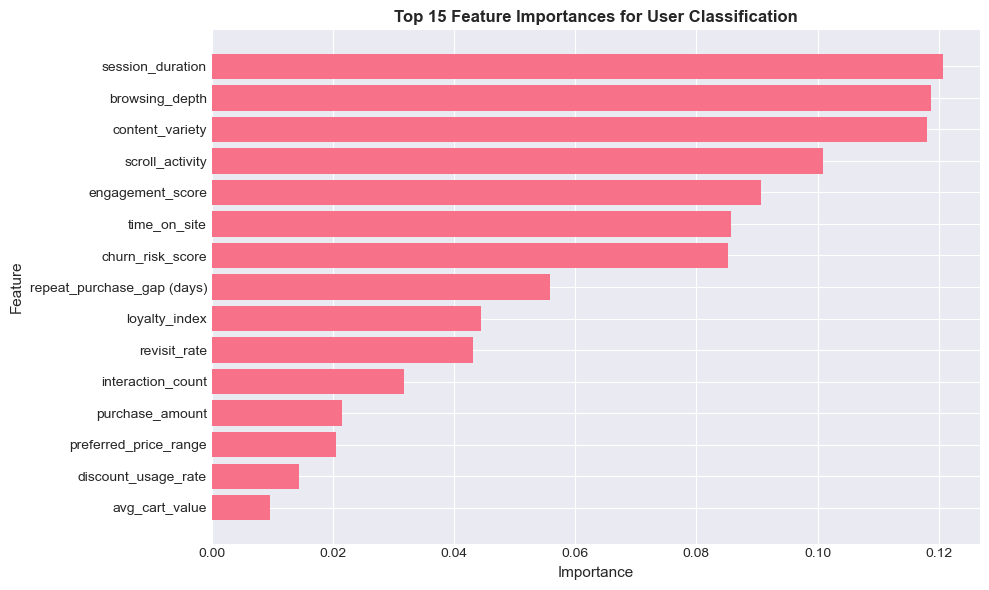


Top 15 Important Features:
                   feature  importance
          session_duration    0.120792
            browsing_depth    0.118785
           content_variety    0.118152
           scroll_activity    0.100976
          engagement_score    0.090730
              time_on_site    0.085759
          churn_risk_score    0.085272
repeat_purchase_gap (days)    0.055853
             loyalty_index    0.044379
              revisit_rate    0.043168
         interaction_count    0.031730
           purchase_amount    0.021555
     preferred_price_range    0.020533
       discount_usage_rate    0.014421
            avg_cart_value    0.009572


In [9]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': user_classifier.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
top_n = min(15, len(feature_importance))
plt.barh(feature_importance['feature'][:top_n], feature_importance['importance'][:top_n])
plt.xlabel('Importance', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.title(f'Top {top_n} Feature Importances for User Classification', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTop {top_n} Important Features:")
print(feature_importance.head(top_n).to_string(index=False))

# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


In [10]:
# Initialize the reward sampler
# Replace with your actual roll number (e.g., for U2023001, use 1)
ROLL_NUMBER = 155  # CHANGE THIS TO YOUR ROLL NUMBER

reward_sampler = sampler(ROLL_NUMBER)

print(f"Reward sampler initialized with roll number: {ROLL_NUMBER}")
print("\nTesting sampler with a few arm pulls:")
for arm in [0, 4, 8]:
    reward = reward_sampler.sample(arm)
    print(f"  Arm {arm}: Reward = {reward:.4f}")

Reward sampler initialized with roll number: 155

Testing sampler with a few arm pulls:
  Arm 0: Reward = 6.8810
  Arm 4: Reward = -10.4604
  Arm 8: Reward = -2.5406


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

In [11]:
# Define arm mapping
NEWS_CATEGORIES = ['Entertainment', 'Education', 'Tech', 'Crime']
USER_CONTEXTS = ['User1', 'User2', 'User3']
NUM_ARMS = 12  # 4 categories × 3 user contexts

# Create arm to (user, category) mapping
arm_mapping = {}
arm_index = 0
for user_idx, user in enumerate(USER_CONTEXTS):
    for cat_idx, category in enumerate(NEWS_CATEGORIES):
        arm_mapping[arm_index] = {
            'user': user,
            'user_idx': user_idx,
            'category': category,
            'cat_idx': cat_idx
        }
        arm_index += 1

# Display mapping
print("Arm Mapping:")
print("="*60)
for arm, info in arm_mapping.items():
    print(f"Arm {arm:2d}: {info['user']:5s} - {info['category']:13s}")

# Helper function to get arm index
def get_arm_index(user_context_idx, category_idx):
    """Get arm index given user context (0-2) and category (0-3)"""
    return user_context_idx * 4 + category_idx

# Helper function to get valid arms for a user context
def get_user_arms(user_context_idx):
    """Get list of valid arm indices for a given user context"""
    return list(range(user_context_idx * 4, (user_context_idx + 1) * 4))

print("\nHelper functions defined!")

Arm Mapping:
Arm  0: User1 - Entertainment
Arm  1: User1 - Education    
Arm  2: User1 - Tech         
Arm  3: User1 - Crime        
Arm  4: User2 - Entertainment
Arm  5: User2 - Education    
Arm  6: User2 - Tech         
Arm  7: User2 - Crime        
Arm  8: User3 - Entertainment
Arm  9: User3 - Education    
Arm 10: User3 - Tech         
Arm 11: User3 - Crime        

Helper functions defined!


## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [12]:
class EpsilonGreedyContextual:
    def __init__(self, n_arms, epsilon=0.1):
        """
        Epsilon-Greedy Contextual Bandit
        
        Args:
            n_arms: Total number of arms (12 in our case)
            epsilon: Exploration probability
        """
        self.n_arms = n_arms
        self.epsilon = epsilon
        
        # Initialize Q-values (average rewards) for each arm
        self.Q = np.zeros(n_arms)
        
        # Count of times each arm was pulled
        self.N = np.zeros(n_arms)
        
        # Total reward collected
        self.total_reward = 0
        
        # Reward history
        self.reward_history = []
        
    def select_arm(self, context):
        """
        Select an arm based on epsilon-greedy strategy
        
        Args:
            context: User context (0, 1, or 2 for User1, User2, User3)
        
        Returns:
            Selected arm index
        """
        # Get valid arms for this context
        valid_arms = get_user_arms(context)
        
        # Epsilon-greedy selection
        if np.random.random() < self.epsilon:
            # Explore: random arm from valid arms
            return np.random.choice(valid_arms)
        else:
            # Exploit: best arm from valid arms
            valid_Q = [self.Q[arm] for arm in valid_arms]
            best_arm_idx = np.argmax(valid_Q)
            return valid_arms[best_arm_idx]
    
    def update(self, arm, reward):
        """
        Update Q-value after receiving reward
        
        Args:
            arm: Arm that was pulled
            reward: Reward received
        """
        self.N[arm] += 1
        
        # Incremental update of Q-value
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]
        
        self.total_reward += reward
        self.reward_history.append(reward)
    
    def get_average_reward(self):
        """Get average reward so far"""
        if len(self.reward_history) == 0:
            return 0
        return self.total_reward / len(self.reward_history)

print("Epsilon-Greedy Contextual Bandit class defined!")

Epsilon-Greedy Contextual Bandit class defined!


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [13]:
class UCBContextual:
    def __init__(self, n_arms, c=2.0):
        """
        UCB Contextual Bandit
        
        Args:
            n_arms: Total number of arms
            c: Exploration parameter (controls confidence bound width)
        """
        self.n_arms = n_arms
        self.c = c
        
        # Initialize Q-values
        self.Q = np.zeros(n_arms)
        
        # Count of times each arm was pulled
        self.N = np.zeros(n_arms)
        
        # Total number of steps
        self.t = 0
        
        # Total reward
        self.total_reward = 0
        
        # Reward history
        self.reward_history = []
        
    def select_arm(self, context):
        """
        Select an arm based on UCB strategy
        
        Args:
            context: User context (0, 1, or 2)
        
        Returns:
            Selected arm index
        """
        self.t += 1
        
        # Get valid arms for this context
        valid_arms = get_user_arms(context)
        
        # Pull each valid arm at least once
        for arm in valid_arms:
            if self.N[arm] == 0:
                return arm
        
        # Calculate UCB values for valid arms
        ucb_values = []
        for arm in valid_arms:
            exploration_bonus = self.c * np.sqrt(np.log(self.t) / self.N[arm])
            ucb = self.Q[arm] + exploration_bonus
            ucb_values.append(ucb)
        
        # Select arm with highest UCB value
        best_idx = np.argmax(ucb_values)
        return valid_arms[best_idx]
    
    def update(self, arm, reward):
        """
        Update Q-value after receiving reward
        
        Args:
            arm: Arm that was pulled
            reward: Reward received
        """
        self.N[arm] += 1
        
        # Incremental update
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]
        
        self.total_reward += reward
        self.reward_history.append(reward)
    
    def get_average_reward(self):
        """Get average reward so far"""
        if len(self.reward_history) == 0:
            return 0
        return self.total_reward / len(self.reward_history)

print("UCB Contextual Bandit class defined!")

UCB Contextual Bandit class defined!


## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [14]:
class SoftMaxContextual:
    def __init__(self, n_arms, tau=1.0):
        """
        SoftMax (Boltzmann Exploration) Contextual Bandit
        
        Args:
            n_arms: Total number of arms
            tau: Temperature parameter (controls exploration)
                 Higher tau = more exploration
                 Lower tau = more exploitation
        """
        self.n_arms = n_arms
        self.tau = tau
        
        # Initialize Q-values
        self.Q = np.zeros(n_arms)
        
        # Count of times each arm was pulled
        self.N = np.zeros(n_arms)
        
        # Total reward
        self.total_reward = 0
        
        # Reward history
        self.reward_history = []
        
    def select_arm(self, context):
        """
        Select an arm based on SoftMax (Boltzmann) distribution
        
        Args:
            context: User context (0, 1, or 2)
        
        Returns:
            Selected arm index
        """
        # Get valid arms for this context
        valid_arms = get_user_arms(context)
        
        # Get Q-values for valid arms
        valid_Q = np.array([self.Q[arm] for arm in valid_arms])
        
        # Calculate softmax probabilities
        # Subtract max for numerical stability
        exp_Q = np.exp((valid_Q - np.max(valid_Q)) / self.tau)
        probabilities = exp_Q / np.sum(exp_Q)
        
        # Sample arm according to probabilities
        selected_idx = np.random.choice(len(valid_arms), p=probabilities)
        return valid_arms[selected_idx]
    
    def update(self, arm, reward):
        """
        Update Q-value after receiving reward
        
        Args:
            arm: Arm that was pulled
            reward: Reward received
        """
        self.N[arm] += 1
        
        # Incremental update
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]
        
        self.total_reward += reward
        self.reward_history.append(reward)
    
    def get_average_reward(self):
        """Get average reward so far"""
        if len(self.reward_history) == 0:
            return 0
        return self.total_reward / len(self.reward_history)

print("SoftMax Contextual Bandit class defined!")

SoftMax Contextual Bandit class defined!


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [15]:
# Simulation parameters
T = 10000  # Number of time steps

# Hyperparameters to test
epsilon_values = [0.01, 0.1, 0.2]
ucb_c_values = [0.5, 1.0, 2.0]
tau_values = [0.5, 1.0, 2.0]

print(f"Simulation Configuration:")
print(f"  Time steps: {T}")
print(f"  Number of arms: {NUM_ARMS}")
print(f"\nHyperparameters to test:")
print(f"  Epsilon-Greedy: ε = {epsilon_values}")
print(f"  UCB: c = {ucb_c_values}")
print(f"  SoftMax: τ = {tau_values}")

Simulation Configuration:
  Time steps: 10000
  Number of arms: 12

Hyperparameters to test:
  Epsilon-Greedy: ε = [0.01, 0.1, 0.2]
  UCB: c = [0.5, 1.0, 2.0]
  SoftMax: τ = [0.5, 1.0, 2.0]


In [16]:
def run_bandit_simulation(bandit, sampler, X_test_data, classifier, T):
    """
    Run bandit simulation for T steps
    
    Args:
        bandit: Bandit algorithm instance
        sampler: Reward sampler
        X_test_data: Test features
        classifier: Trained user classifier
        T: Number of time steps
    
    Returns:
        Dictionary with cumulative rewards and metrics
    """
    cumulative_rewards = []
    cumulative_reward = 0
    arm_pulls = np.zeros(NUM_ARMS)
    
    for t in range(T):
        # Sample a random user from test set
        user_idx = np.random.randint(0, len(X_test_data))
        user_features = X_test_data.iloc[user_idx:user_idx+1]
        
        # Predict user context using classifier
        user_context = classifier.predict(user_features)[0]
        
        # Select arm based on bandit strategy
        arm = bandit.select_arm(user_context)
        
        # Get reward from sampler
        reward = sampler.sample(arm)
        
        # Update bandit
        bandit.update(arm, reward)
        
        # Track metrics
        cumulative_reward += reward
        cumulative_rewards.append(cumulative_reward)
        arm_pulls[arm] += 1
    
    return {
        'cumulative_rewards': cumulative_rewards,
        'average_reward': bandit.get_average_reward(),
        'arm_pulls': arm_pulls,
        'Q_values': bandit.Q.copy(),
        'reward_history': bandit.reward_history
    }

print("Simulation function defined!")

Simulation function defined!


In [ ]:
# Run Epsilon-Greedy simulations
print("Running Epsilon-Greedy simulations...")
print("="*60)
epsilon_results = {}

for eps in epsilon_values:
    print(f"\nTesting ε = {eps}")
    bandit = EpsilonGreedyContextual(NUM_ARMS, epsilon=eps)
    results = run_bandit_simulation(bandit, reward_sampler, X_test, user_classifier, T)
    epsilon_results[eps] = results
    print(f"  Average Reward: {results['average_reward']:.4f}")
    print(f"  Total Reward: {results['cumulative_rewards'][-1]:.2f}")

print("\nEpsilon-Greedy simulations complete!")

Running Epsilon-Greedy simulations...

Testing ε = 0.01
  Average Reward: 4.4865
  Total Reward: 44864.70

Testing ε = 0.1
  Average Reward: 4.1368
  Total Reward: 41367.73

Testing ε = 0.2
  Average Reward: 3.5928
  Total Reward: 35927.85

Epsilon-Greedy simulations complete!


In [18]:
# Run UCB simulations
print("Running UCB simulations...")
print("="*60)
ucb_results = {}

for c in ucb_c_values:
    print(f"\nTesting c = {c}")
    bandit = UCBContextual(NUM_ARMS, c=c)
    results = run_bandit_simulation(bandit, reward_sampler, X_test, user_classifier, T)
    ucb_results[c] = results
    print(f"  Average Reward: {results['average_reward']:.4f}")
    print(f"  Total Reward: {results['cumulative_rewards'][-1]:.2f}")

print("\nUCB simulations complete!")

Running UCB simulations...

Testing c = 0.5
  Average Reward: 4.6339
  Total Reward: 46338.83

Testing c = 1.0
  Average Reward: 4.6494
  Total Reward: 46493.83

Testing c = 2.0
  Average Reward: 4.6213
  Total Reward: 46212.77

UCB simulations complete!


In [19]:
# Run SoftMax simulations
print("Running SoftMax simulations...")
print("="*60)
softmax_results = {}

for tau in tau_values:
    print(f"\nTesting τ = {tau}")
    bandit = SoftMaxContextual(NUM_ARMS, tau=tau)
    results = run_bandit_simulation(bandit, reward_sampler, X_test, user_classifier, T)
    softmax_results[tau] = results
    print(f"  Average Reward: {results['average_reward']:.4f}")
    print(f"  Total Reward: {results['cumulative_rewards'][-1]:.2f}")

print("\nSoftMax simulations complete!")

Running SoftMax simulations...

Testing τ = 0.5
  Average Reward: 4.5809
  Total Reward: 45809.30

Testing τ = 1.0
  Average Reward: 4.3999
  Total Reward: 43999.33

Testing τ = 2.0
  Average Reward: 3.9722
  Total Reward: 39721.55

SoftMax simulations complete!


## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


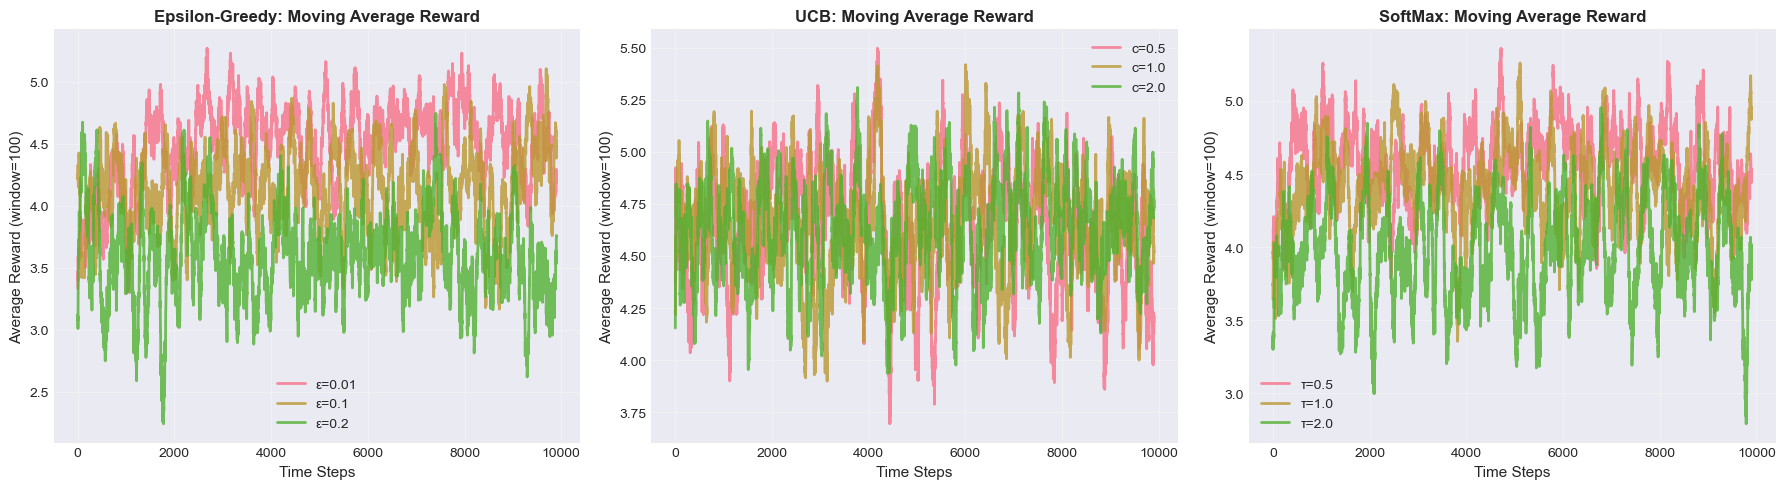

In [20]:
# Calculate and plot moving average rewards
def moving_average(data, window=100):
    """Calculate moving average with given window size"""
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
window = 100

# Epsilon-Greedy
for eps, results in epsilon_results.items():
    avg_rewards = moving_average(results['reward_history'], window)
    axes[0].plot(avg_rewards, label=f'ε={eps}', alpha=0.8, linewidth=2)
axes[0].set_xlabel('Time Steps', fontsize=11)
axes[0].set_ylabel(f'Average Reward (window={window})', fontsize=11)
axes[0].set_title('Epsilon-Greedy: Moving Average Reward', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# UCB
for c, results in ucb_results.items():
    avg_rewards = moving_average(results['reward_history'], window)
    axes[1].plot(avg_rewards, label=f'c={c}', alpha=0.8, linewidth=2)
axes[1].set_xlabel('Time Steps', fontsize=11)
axes[1].set_ylabel(f'Average Reward (window={window})', fontsize=11)
axes[1].set_title('UCB: Moving Average Reward', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# SoftMax
for tau, results in softmax_results.items():
    avg_rewards = moving_average(results['reward_history'], window)
    axes[2].plot(avg_rewards, label=f'τ={tau}', alpha=0.8, linewidth=2)
axes[2].set_xlabel('Time Steps', fontsize=11)
axes[2].set_ylabel(f'Average Reward (window={window})', fontsize=11)
axes[2].set_title('SoftMax: Moving Average Reward', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Best Configurations:
Epsilon-Greedy: ε=0.01, Avg Reward=4.4865
UCB:            c=1.0, Avg Reward=4.6494
SoftMax:        τ=0.5, Avg Reward=4.5809


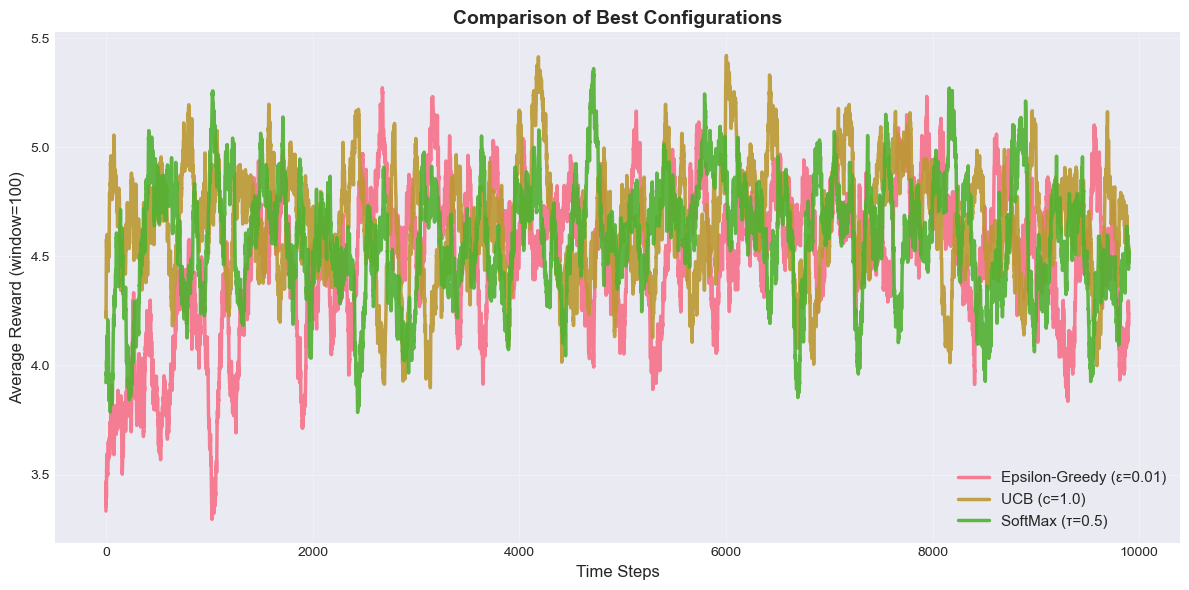

In [21]:
# Compare best configuration from each algorithm
best_epsilon = max(epsilon_results.items(), key=lambda x: x[1]['average_reward'])
best_ucb = max(ucb_results.items(), key=lambda x: x[1]['average_reward'])
best_softmax = max(softmax_results.items(), key=lambda x: x[1]['average_reward'])

print("Best Configurations:")
print("="*70)
print(f"Epsilon-Greedy: ε={best_epsilon[0]}, Avg Reward={best_epsilon[1]['average_reward']:.4f}")
print(f"UCB:            c={best_ucb[0]}, Avg Reward={best_ucb[1]['average_reward']:.4f}")
print(f"SoftMax:        τ={best_softmax[0]}, Avg Reward={best_softmax[1]['average_reward']:.4f}")

# Plot comparison
plt.figure(figsize=(12, 6))
window = 100

plt.plot(moving_average(best_epsilon[1]['reward_history'], window),
         label=f'Epsilon-Greedy (ε={best_epsilon[0]})', linewidth=2.5, alpha=0.9)
plt.plot(moving_average(best_ucb[1]['reward_history'], window),
         label=f'UCB (c={best_ucb[0]})', linewidth=2.5, alpha=0.9)
plt.plot(moving_average(best_softmax[1]['reward_history'], window),
         label=f'SoftMax (τ={best_softmax[0]})', linewidth=2.5, alpha=0.9)

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel(f'Average Reward (window={window})', fontsize=12)
plt.title('Comparison of Best Configurations', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

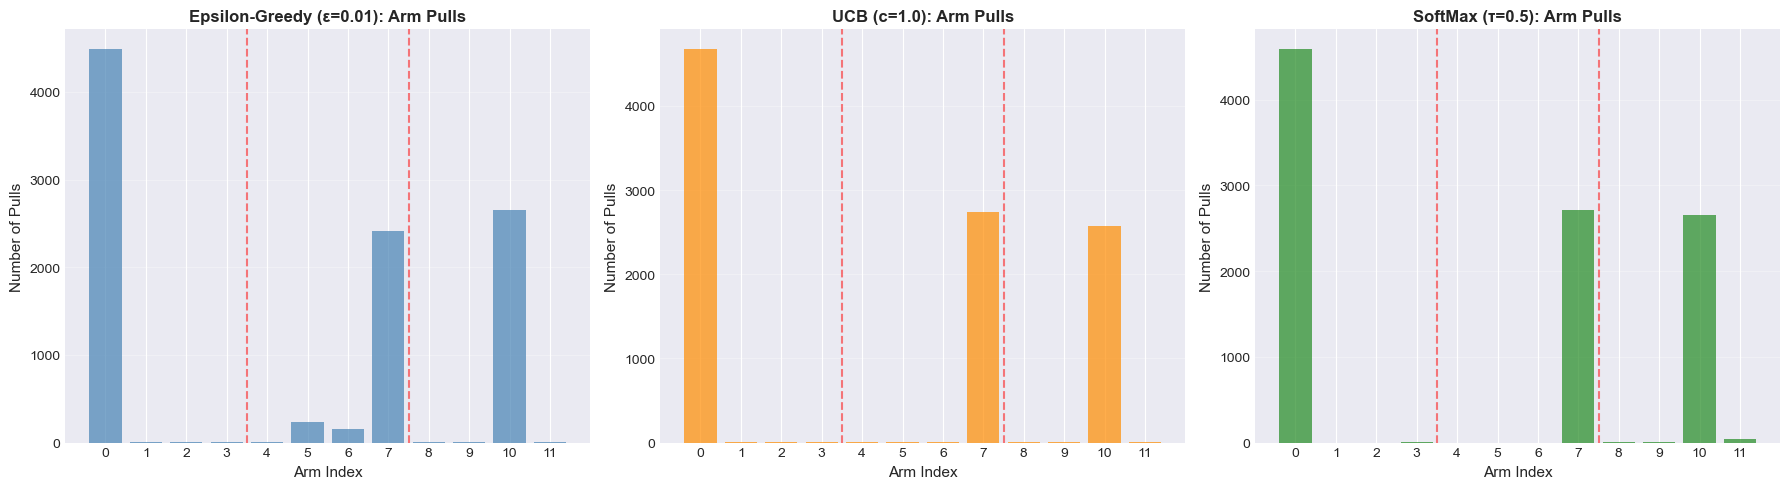


Arm Mapping Reminder:
  Arms 0-3:  User1 (Entertainment, Education, Tech, Crime)
  Arms 4-7:  User2 (Entertainment, Education, Tech, Crime)
  Arms 8-11: User3 (Entertainment, Education, Tech, Crime)


In [22]:
# Analyze arm pull distribution for best configurations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Epsilon-Greedy
axes[0].bar(range(NUM_ARMS), best_epsilon[1]['arm_pulls'], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Arm Index', fontsize=11)
axes[0].set_ylabel('Number of Pulls', fontsize=11)
axes[0].set_title(f'Epsilon-Greedy (ε={best_epsilon[0]}): Arm Pulls', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(NUM_ARMS))
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axvline(x=3.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
axes[0].axvline(x=7.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

# UCB
axes[1].bar(range(NUM_ARMS), best_ucb[1]['arm_pulls'], color='darkorange', alpha=0.7)
axes[1].set_xlabel('Arm Index', fontsize=11)
axes[1].set_ylabel('Number of Pulls', fontsize=11)
axes[1].set_title(f'UCB (c={best_ucb[0]}): Arm Pulls', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(NUM_ARMS))
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axvline(x=3.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
axes[1].axvline(x=7.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

# SoftMax
axes[2].bar(range(NUM_ARMS), best_softmax[1]['arm_pulls'], color='forestgreen', alpha=0.7)
axes[2].set_xlabel('Arm Index', fontsize=11)
axes[2].set_ylabel('Number of Pulls', fontsize=11)
axes[2].set_title(f'SoftMax (τ={best_softmax[0]}): Arm Pulls', fontsize=12, fontweight='bold')
axes[2].set_xticks(range(NUM_ARMS))
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].axvline(x=3.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
axes[2].axvline(x=7.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

plt.tight_layout()
plt.show()

print("\nArm Mapping Reminder:")
print("  Arms 0-3:  User1 (Entertainment, Education, Tech, Crime)")
print("  Arms 4-7:  User2 (Entertainment, Education, Tech, Crime)")
print("  Arms 8-11: User3 (Entertainment, Education, Tech, Crime)")

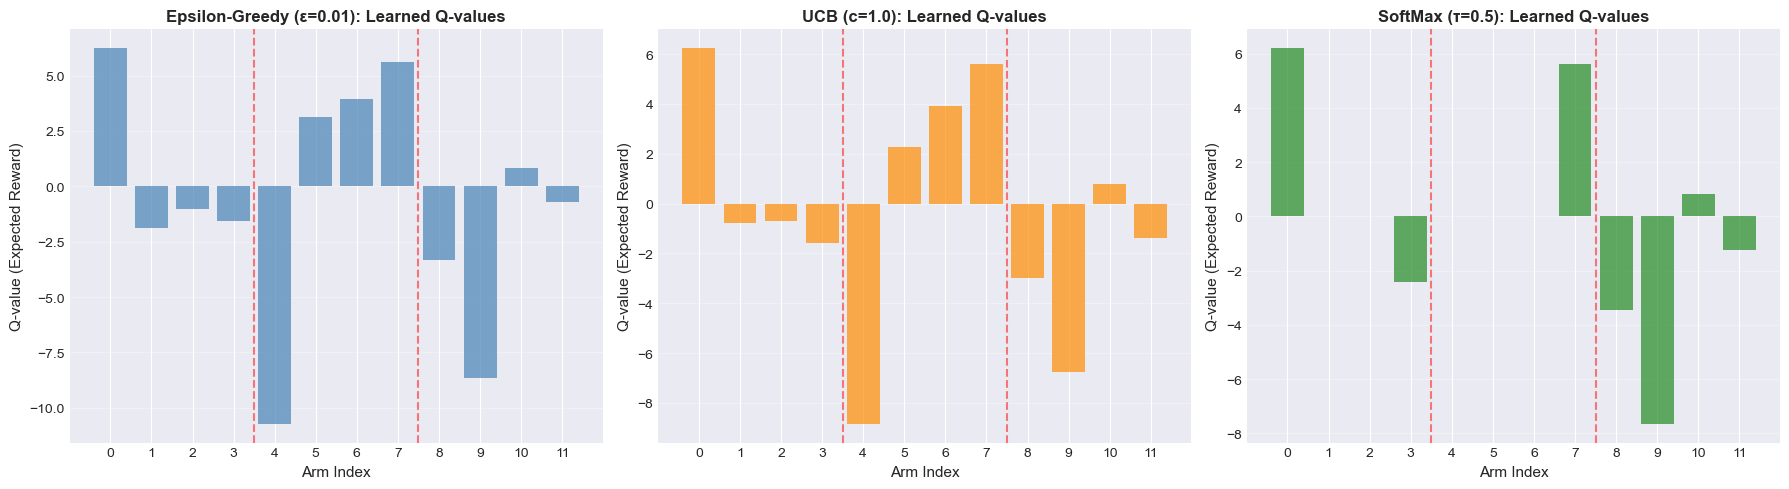


Top 5 Arms by Q-value:

Epsilon-Greedy (ε=0.01):
  1. Arm 0: User1 - Entertainment (Q=6.2342)
  2. Arm 7: User2 - Crime         (Q=5.6308)
  3. Arm 6: User2 - Tech          (Q=3.9577)
  4. Arm 5: User2 - Education     (Q=3.1353)
  5. Arm 10: User3 - Tech          (Q=0.8077)

UCB (c=1.0):
  1. Arm 0: User1 - Entertainment (Q=6.2365)
  2. Arm 7: User2 - Crime         (Q=5.5958)
  3. Arm 6: User2 - Tech          (Q=3.9081)
  4. Arm 5: User2 - Education     (Q=2.2676)
  5. Arm 10: User3 - Tech          (Q=0.7942)

SoftMax (τ=0.5):
  1. Arm 0: User1 - Entertainment (Q=6.1959)
  2. Arm 7: User2 - Crime         (Q=5.5983)
  3. Arm 10: User3 - Tech          (Q=0.8326)
  4. Arm 5: User2 - Education     (Q=0.0000)
  5. Arm 4: User2 - Entertainment (Q=0.0000)


In [23]:
# Analyze learned Q-values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Epsilon-Greedy
axes[0].bar(range(NUM_ARMS), best_epsilon[1]['Q_values'], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Arm Index', fontsize=11)
axes[0].set_ylabel('Q-value (Expected Reward)', fontsize=11)
axes[0].set_title(f'Epsilon-Greedy (ε={best_epsilon[0]}): Learned Q-values', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(NUM_ARMS))
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axvline(x=3.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
axes[0].axvline(x=7.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

# UCB
axes[1].bar(range(NUM_ARMS), best_ucb[1]['Q_values'], color='darkorange', alpha=0.7)
axes[1].set_xlabel('Arm Index', fontsize=11)
axes[1].set_ylabel('Q-value (Expected Reward)', fontsize=11)
axes[1].set_title(f'UCB (c={best_ucb[0]}): Learned Q-values', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(NUM_ARMS))
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axvline(x=3.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
axes[1].axvline(x=7.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

# SoftMax
axes[2].bar(range(NUM_ARMS), best_softmax[1]['Q_values'], color='forestgreen', alpha=0.7)
axes[2].set_xlabel('Arm Index', fontsize=11)
axes[2].set_ylabel('Q-value (Expected Reward)', fontsize=11)
axes[2].set_title(f'SoftMax (τ={best_softmax[0]}): Learned Q-values', fontsize=12, fontweight='bold')
axes[2].set_xticks(range(NUM_ARMS))
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].axvline(x=3.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
axes[2].axvline(x=7.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

plt.tight_layout()
plt.show()

# Print top arms for each algorithm
print("\nTop 5 Arms by Q-value:")
print("="*70)

print(f"\nEpsilon-Greedy (ε={best_epsilon[0]}):")
top_arms = np.argsort(best_epsilon[1]['Q_values'])[::-1][:5]
for rank, arm in enumerate(top_arms, 1):
    print(f"  {rank}. Arm {arm}: {arm_mapping[arm]['user']} - {arm_mapping[arm]['category']:13s} "
          f"(Q={best_epsilon[1]['Q_values'][arm]:.4f})")

print(f"\nUCB (c={best_ucb[0]}):")
top_arms = np.argsort(best_ucb[1]['Q_values'])[::-1][:5]
for rank, arm in enumerate(top_arms, 1):
    print(f"  {rank}. Arm {arm}: {arm_mapping[arm]['user']} - {arm_mapping[arm]['category']:13s} "
          f"(Q={best_ucb[1]['Q_values'][arm]:.4f})")

print(f"\nSoftMax (τ={best_softmax[0]}):")
top_arms = np.argsort(best_softmax[1]['Q_values'])[::-1][:5]
for rank, arm in enumerate(top_arms, 1):
    print(f"  {rank}. Arm {arm}: {arm_mapping[arm]['user']} - {arm_mapping[arm]['category']:13s} "
          f"(Q={best_softmax[1]['Q_values'][arm]:.4f})")